# Stretch: hyperspectral mineral domains from drill core

The main project predicts lithology from **assay geochemistry**. This notebook is a short stretch into the *other* half of a modern core shed: **hyperspectral core scanning**, the domain closest to Datarock's work.

We pull CSIRO HyLogger TSA-derived mineralogy for South Australian drill core from the [AuScope National Virtual Core Library](https://www.auscope.org.au/nvcl/) (same state as the geochemistry), cluster per-depth mineral assemblages into **unsupervised mineral domains**, and plot them downhole — echoing the geochemistry strip log, but built from spectra instead of assays.

All logic lives in [`src/lithoclass/nvcl.py`](../src/lithoclass/nvcl.py); this notebook only narrates. The mineralogy is fetched once and cached, so everything below runs offline.

In [1]:
import os
from pathlib import Path

# this notebook lives in notebooks/; work from the repo root so data paths resolve
if Path.cwd().name == "notebooks":
    os.chdir("..")

In [2]:
import pandas as pd

from lithoclass.nvcl import (
    CACHE_PATH,
    build_domain_matrix,
    cluster_domains,
    cluster_mineral_profiles,
)

long_df = pd.read_parquet(CACHE_PATH)
print(f"{len(long_df):,} classified intervals across {long_df['nvcl_id'].nunique()} holes")
long_df['mineral'].value_counts().head(13)

361,132 classified intervals across 12 holes


mineral
WHITE-MICA    153457
KAOLIN         51740
CARBONATE      43093
SULPHATE       39606
CHLORITE       29480
SMECTITE       24179
EPIDOTE         6170
TOURMALINE      5879
DARK-MICA       5693
OTHER-ALOH      1288
SERPENTINE       315
AMPHIBOLE        218
OTHER-MGOH        14
Name: count, dtype: int64

These are TSA (The Spectral Assistant) mineral-group identifications from short-wave infrared reflectance — white mica, kaolin, carbonate, sulphate, chlorite, smectite and so on. Each ~1 cm interval carries a dominant and second mineral with abundance weights.

## Building mineral-domain vectors

We bin the core to 1 m, turn each interval into a **mineral-proportion vector**, and cluster with KMeans. Unlike geochemistry, mineral proportions have *structural* zeros (a mineral genuinely absent), so the CLR transform used for the assays is **not** appropriate here — we cluster standardised proportions directly. `k` is chosen by silhouette, rejecting solutions that only score well by isolating outlier intervals.

In [3]:
props, index = build_domain_matrix(long_df, bin_m=1.0)
labels, k, sil = cluster_domains(props)
print(f"{len(props):,} one-metre intervals -> {k} mineral domains (silhouette {sil:.2f})")

profiles = cluster_mineral_profiles(props, labels)
for c in profiles.index:
    top = profiles.loc[c].sort_values(ascending=False).head(3)
    print(f"Domain {c}: " + ", ".join(f"{m} {v:.0%}" for m, v in top.items()))

2,650 one-metre intervals -> 4 mineral domains (silhouette 0.34)
Domain 0: SMECTITE 53%, SULPHATE 24%, WHITE-MICA 20%
Domain 1: WHITE-MICA 71%, CHLORITE 10%, KAOLIN 4%
Domain 2: KAOLIN 75%, WHITE-MICA 13%, CARBONATE 4%
Domain 3: CARBONATE 52%, WHITE-MICA 23%, SULPHATE 5%


The clusters are geologically legible without any labels: a **white-mica** (phyllic) domain, a **kaolin** (argillic / weathering) domain, a **carbonate** domain, and a **smectite + sulphate** (evaporitic / weathered) domain. These are exactly the alteration/mineralogical domains a geologist would map from the core by eye.

## Downhole domains

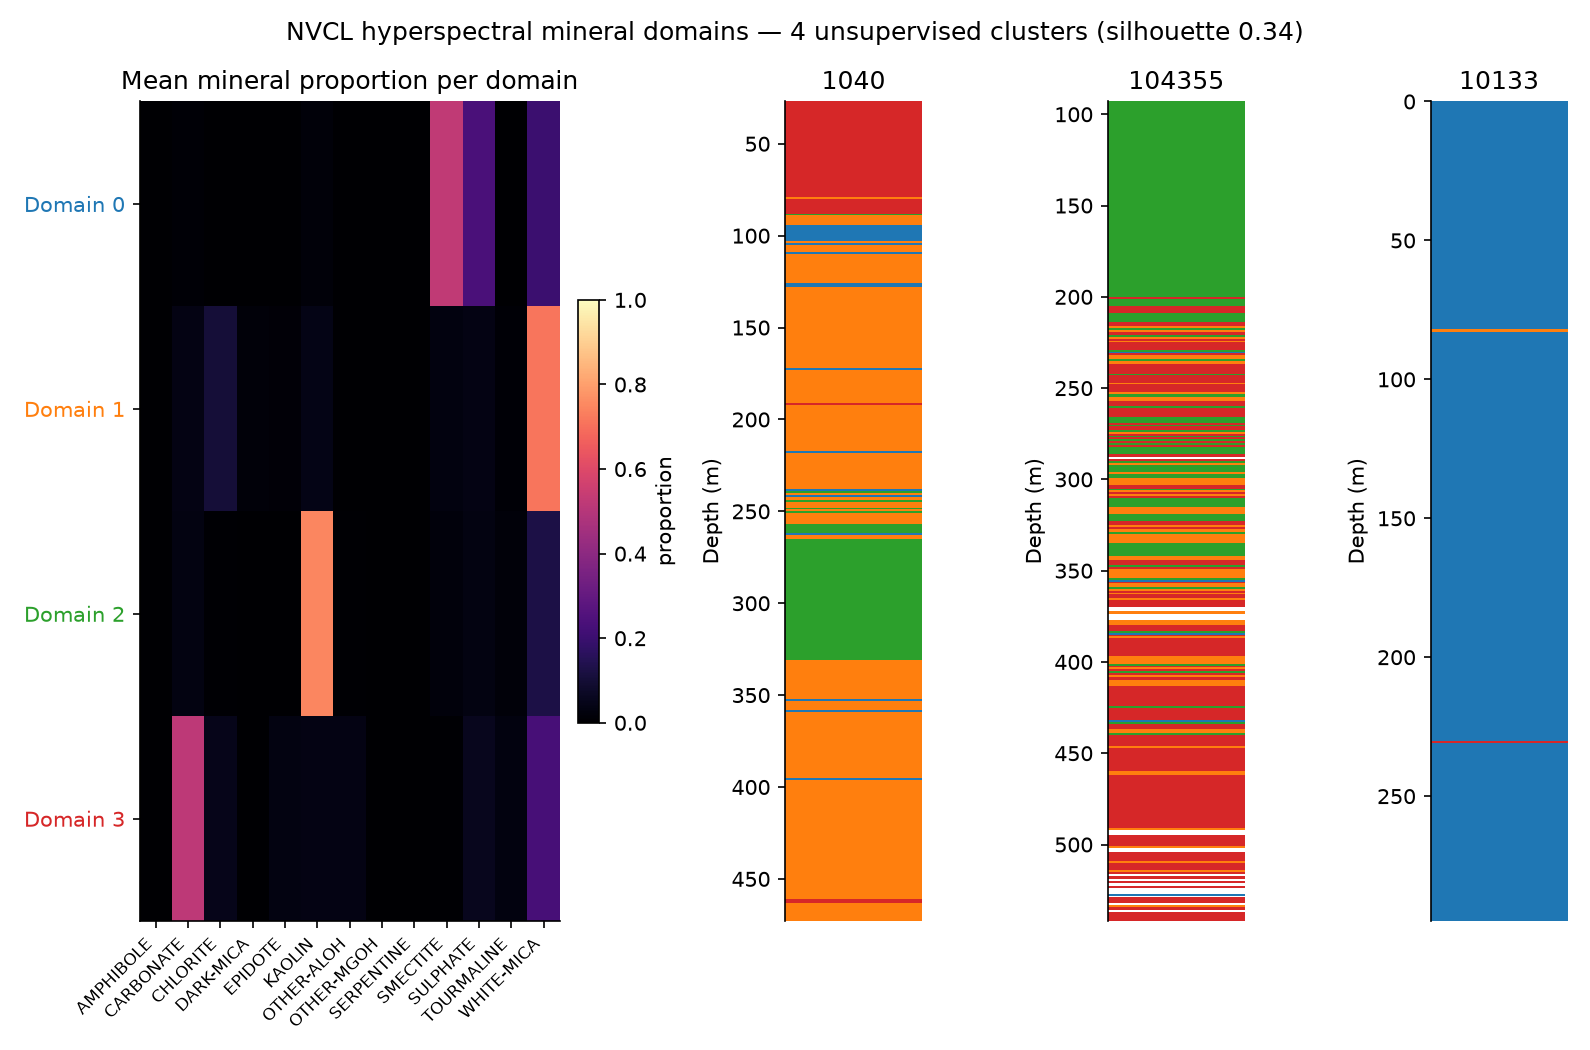

In [4]:
from IPython.display import Image

from lithoclass.nvcl import make_figure

Image(str(make_figure()))

The strips show coherent downhole zonation — mineral domains that persist over tens of metres, not random flicker — recovered with no supervision at all.

**Honest scope.** This is exploratory pattern discovery: there is no ground truth, the clustering is sensitive to `k` and binning, and only 12 SA holes are used. It is a demonstration that the same clean-data / honest-method habits from the geochemistry work transfer to hyperspectral core-scanning data — the world Datarock operates in — not a validated product.

*Data © Geological Survey of South Australia via AuScope NVCL, CC-BY 4.0.*